In [2]:
import zipfile

zip_path = "traffic.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("traffic_data")

print("Unzipping completed!")

Unzipping completed!


In [3]:
import os

os.listdir("traffic_data")

['traffic.csv']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
file_path = "traffic_data/traffic.csv"

df = pd.read_csv(file_path)

df.head()


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [6]:
df.shape


(226278, 9)

In [7]:
df.columns


Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [9]:
df.isnull().sum()


,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [10]:
df = df.dropna()
print("Missing values removed")


Missing values removed


In [11]:
df.describe()


,event,date,country,city,artist,album,track,isrc,linkid
count,219149,219149,219149,219149,219149,219149,219149,219149,219149
unique,3,7,211,11690,590,676,693,709,743
top,pageview,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,137115,34079,46960,22588,40841,40841,40841,40841,40841


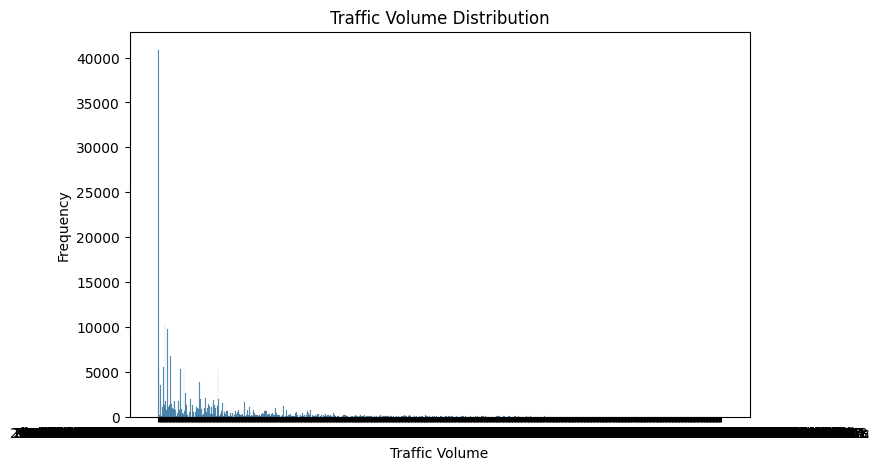

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df.iloc[:, -1], bins=30)
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()


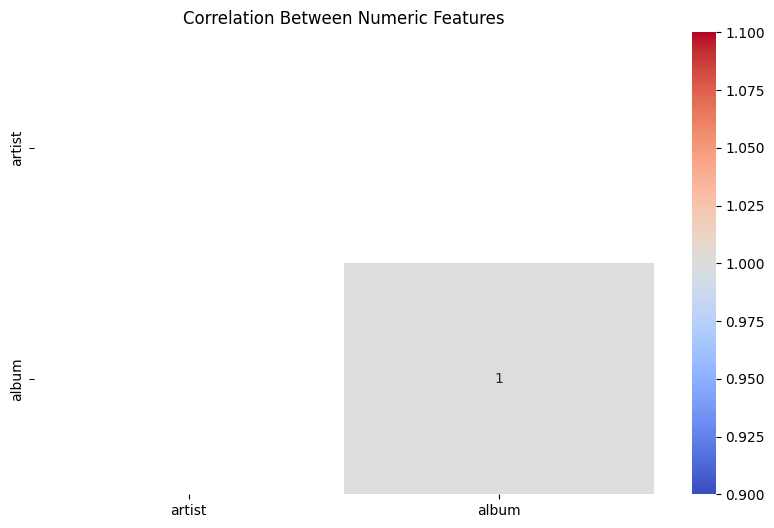

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_numeric = df.apply(pd.to_numeric, errors='coerce')


df_numeric = df_numeric.dropna(axis=1, how='all')


if df_numeric.shape[1] >= 2:
    plt.figure(figsize=(10,6))
    sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Between Numeric Features")
    plt.show()
else:
    print("❌ Correlation heatmap cannot be generated because dataset has no numeric columns.")
